In [9]:
import pystac_client
import torch
import torch.nn as nn
import torchvision.transforms as T
import numpy as np
from planetary_computer import sign
import stackstac
import matplotlib.pyplot as plt
import dask
import math


# Input Bounding box and time stamp

In [10]:
# Configure Dask for better I/O performance
dask.config.set(scheduler="threads")

# --- 1. Configuration & User Inputs ---
BBOX: list = [77.5, 12.8, 78.0, 13.2]
TIME_RANGE: str = "2022-01-01/2022-01-31"
MODEL_PATH: str = r"C:\Users\HP\SKYSERVE\ResNet_classification_Model.pth"
CLASS_NAMES: list[str] = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
    'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'
]
NUM_CLASSES: int = len(CLASS_NAMES)
# --- MODIFIED SECTION ---
# 640m / 10m resolution = 64 pixels
PATCH_SIZE: int = 64 # Define the size of the smaller images to classify
#PATCH_SIZE: int = 256 # Define the size of the smaller images to classify

NUM_RANDOM_PATCHES: int = 30 # How many random patches to classify


# Model Architecture Definition

In [11]:
def conv3x3(in_channels: int, out_channels: int, stride: int = 1) -> nn.Module:
    return nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1, downsample: nn.Module | None = None):
        super(ResidualBlock, self).__init__()
        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        return self.relu(out)

class ResNet(nn.Module):
    def __init__(self, block: type[ResidualBlock], layers: list[int], num_classes: int = 10):
        super(ResNet, self).__init__()
        self.in_channels = 16
        self.conv = conv3x3(3, 16)
        self.bn = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(block, 16, layers[0])
        self.layer2 = self._make_layer(block, 32, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 64, layers[2], stride=2)
        self.avg_pool = nn.AvgPool2d(16)
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, block: type[ResidualBlock], out_channels: int, blocks: int, stride: int = 1) -> nn.Module:
        downsample = None
        if (stride != 1) or (self.in_channels != out_channels):
            downsample = nn.Sequential(
                conv3x3(self.in_channels, out_channels, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        layers = [block(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.relu(self.bn(self.conv(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        return self.fc(out)

#  Pipeline Functions

# getting Sentinel 2 images

In [12]:
def fetch_satellite_image(
    bbox: list, time_range: str, catalog: pystac_client.Client
) -> np.ndarray | None:
    """Fetches and prepares a single, large satellite image array."""
    print("Searching for satellite imagery...")
    search = catalog.search(
        collections=["sentinel-2-l2a"], bbox=bbox, datetime=time_range,
        query={"eo:cloud_cover": {"lt": 10}},
    )
    items = search.item_collection()
    if not items:
        print("❌ No items found.")
        return None
        
    print(f"✅ Found {len(items)} items. Creating a composite image.")
    stack = stackstac.stack(
        sign(items), assets=["B04", "B03", "B02"], resolution=10,
        bounds_latlon=bbox, epsg=32643
    )
    image_data = stack.isel(time=0).compute()
    
    scaled_array = np.clip(image_data.values, 0, 3000) / 3000.0
    return scaled_array

In [13]:
def classify_patch(patch_tensor: torch.Tensor, model: nn.Module) -> str:
    """Classifies a single image patch."""
    transform = T.Compose([
        T.Resize((64, 64), antialias=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = transform(patch_tensor).unsqueeze(0)
    with torch.no_grad():
        output = model(input_tensor)
        pred_index = output.argmax(dim=1).item()
    return CLASS_NAMES[pred_index]

# MAIN

Loading ResNet model...
Searching for satellite imagery...
✅ Found 3 items. Creating a composite image.
Dividing the large image into 64x64 patches...
Created 5950 total patches.
Randomly selecting 30 of them for classification.
Classifying 30 patches...


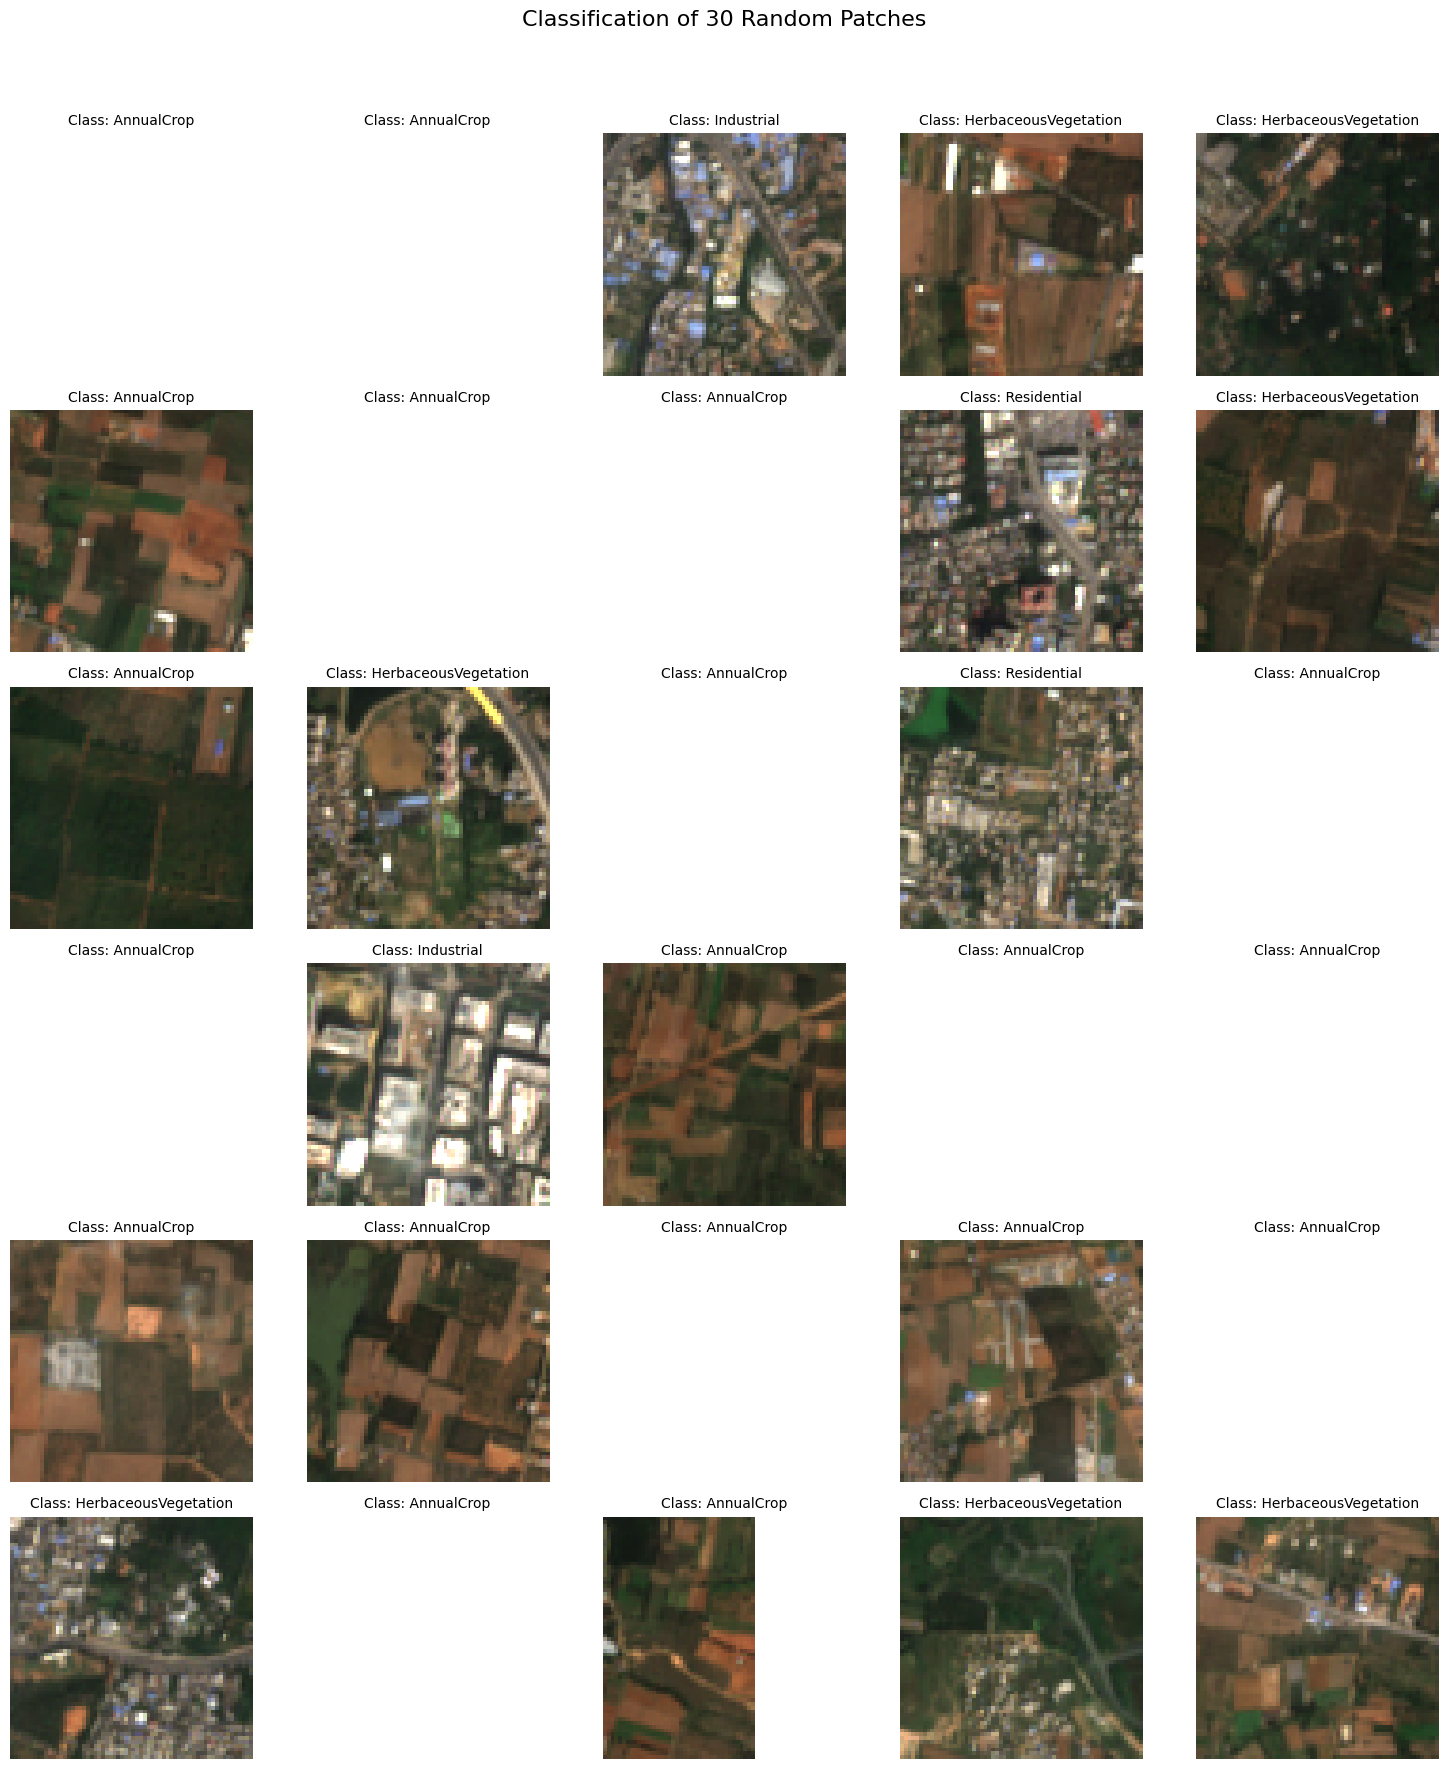

In [16]:
if __name__ == "__main__":
    print("Loading ResNet model...")
    model = ResNet(ResidualBlock, [2, 2, 2], num_classes=NUM_CLASSES)
    
    try:
        model.load_state_dict(torch.load(MODEL_PATH))
        model.eval()
    except Exception as e:
        print(f"❌ An error occurred while loading the model: {e}")
    else:
        catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
        
        large_image_array = fetch_satellite_image(BBOX, TIME_RANGE, catalog)
        
        if large_image_array is not None:
            print(f"Dividing the large image into {PATCH_SIZE}x{PATCH_SIZE} patches...")
            all_patches = []
            _, h, w = large_image_array.shape
            for i in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
                for j in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):
                    patch = large_image_array[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
                    all_patches.append(patch)
            
            if not all_patches:
                print("Image is smaller than the patch size. No patches were created.")
            else:
                # --- MODIFIED LOGIC: Randomly sample patches ---
                print(f"Created {len(all_patches)} total patches.")
                if len(all_patches) > NUM_RANDOM_PATCHES:
                    sampled_patches = random.sample(all_patches, NUM_RANDOM_PATCHES)
                    print(f"Randomly selecting {NUM_RANDOM_PATCHES} of them for classification.")
                else:
                    sampled_patches = all_patches
                    print(f"Using all {len(all_patches)} available patches as it's less than {NUM_RANDOM_PATCHES}.")

                print(f"Classifying {len(sampled_patches)} patches...")
                predictions = [classify_patch(torch.from_numpy(p).float(), model) for p in sampled_patches]
                
                # Display the results in a grid
                num_cols = 5 
                num_rows = math.ceil(len(sampled_patches) / num_cols)
                fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 3))
                fig.suptitle(f"Classification of {len(sampled_patches)} Random Patches", fontsize=16)
                
                for i, (patch, prediction) in enumerate(zip(sampled_patches, predictions)):
                    ax = axes.flat[i]
                    display_patch = np.moveaxis(patch, 0, -1)
                    ax.imshow(display_patch)
                    ax.set_title(f"Class: {prediction}", fontsize=10)
                    ax.axis('off')
                
                # Hide any unused subplots
                for i in range(len(sampled_patches), len(axes.flat)):
                    axes.flat[i].axis('off')
                    
                plt.tight_layout(rect=[0, 0, 1, 0.95])
                plt.show()